# Sensitivity limits for LZ (2022) and XENONnT (2022)

Here we show how to perform a grid scan of NSI parameters. For the sake of time, we show how to do a 1-binned analysis and with only one xenon isotope.  

In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


from snudd import config
from snudd.targets import Electron
from snudd.binding import binding_xe
from snudd.rrpa    import rrpa_scaling
from snudd.targets import Nucleus


from snudd.models  import GeneralNSI

from snudd.resolution import Resolution, Convolver # deals with the resolution effects on the rate


from snudd.efficiencies import efficiency_xnt_er_22 # efficiency curve from arxiv.org:2207.11330
from snudd.resolution   import res_xnt_er

from snudd.efficiencies import efficiency_lz_nr, efficiency_lz_nr_22 # efficiency curve from arxiv:2207.03764
from snudd.resolution   import res_lz_nr


We define functions that convolute the theoretical spectrum with the detector effects and multiply with the exposrue to get counts.

In [2]:
def counts_LZ22_NR(signal, E_Rs):
    exposure = 60*(1/365.25)*5.5 # in tn yr-1
    acceptance_cut = 0.9
    convolution_lz_sig = Convolver(E_Rs, signal , efficiency_lz_nr_22, res_lz_nr)
    return convolution_lz_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure*acceptance_cut

In [3]:
def counts_xnt_ER(signal, E_Rs):
    exposure = 1.16 # in tn yr-1
    acceptance_cut = 0.91  # 91% is quoted in 2207.11330
    convolution_xnt_sig= Convolver(E_Rs, signal , efficiency_xnt_er_22, res_xnt_er)
    
    return convolution_xnt_sig.convolved_binned_rate(1.0e-7, 3.0e-5)*exposure*acceptance_cut

### Setting up the parameter grids

We generate a 2D grid of NSI values $\varepsilon$ and angles $\varphi$.

In [4]:
phispace = np.linspace(-np.pi/2, np.pi/2,5) # phi domain
eps_space = np.linspace(3.0, -3.0, 5) # epsilon domain

phiGrid, epsGrid = np.meshgrid(phispace, eps_space, indexing='ij')

In [5]:
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling)

In [6]:
E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered

In [7]:
N_xnt22 = np.zeros(np.shape(phiGrid))
N_LZ = np.zeros(np.shape(phiGrid))

### Computing number of events for LZ and XENONnT

Below we calculate the ER and NR counts for each grid point for an active NSI $\varepsilon_{e\mu}$. Because there are some large NSI parameters in the grid, SNuDD warns you the adiabatic apprximation may not be valid. 

In [ ]:
from   multiprocess import Pool


parallel = True
nproc = 8 # Number of parallel processes



# Construct index list for grid computation
args  = []
for i in range(len(phispace)):
    for j in range(len(eps_space)):
        args.append((i,j))




def calc_events(n):
    """Calculate the number of signal events in LZ and Xenon for the grid point (i,j)"""

    i, j = args[n]

    # Define NSI model
    NSI_matrix_tmp = np.array([[0.0, 1.0, 0.0],
                                [1.0, 0.0, 0.0],
                                [0.0, 0.0, 0.0]])*epsGrid[i,j]

    NSI_eta = 0.0
    NSI_phi_tmp = phiGrid[i,j]

    NSI_model_tmp = GeneralNSI(NSI_matrix_tmp, NSI_eta, NSI_phi_tmp)
    
    Xe_electron.update_model(NSI_model_tmp)
    Xe_nucleus.update_model(NSI_model_tmp)
    
    # Compute solar density matrix
    Xe_electron.prepare_density()
    Xe_nucleus.prepare_density()

    # Calculate theoretical rate
    tmp_spec_NR = Xe_nucleus.spectrum(E_Rs)
    tmp_spec_ER = Xe_electron.spectrum(E_Rs)
    
    N_LZ[i,j] = counts_LZ22_NR(np.array(tmp_spec_NR).T, E_Rs )
    N_xnt22[i,j]= counts_xnt_ER(np.array(tmp_spec_ER).T, E_Rs)




    

# Run in parallel mode
if parallel:
    with Pool(processes = nproc) as P:  
        # P.starmap(calc_events, args)
        for result in tqdm(P.imap_unordered(calc_events, range(len(args))), total=len(args), desc='Grid points'):
            pass

# Run in serial mode
else:
    for n in tqdm(range(len(args)), desc='Grid points'):
        calc_events(n)

Grid points:   0%|          | 0/25 [00:00<?, ?it/s]/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_94729/3062162080.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  N_LZ[i,j] = counts_LZ22_NR(np.array(tmp_spec_NR).T, E_Rs )
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_94729/3062162080.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  N_xnt22[i,j]= counts_xnt_ER(np.array(tmp_spec_ER).T, E_Rs)
/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_94729/3062162080.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  N_LZ[i,j] = counts_LZ22_NR(np.array(tmp_spec_NR).T, E_Rs )
Grid points:   4%|▍         | 1/25 [00:10<04:01, 10.05s/it]/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_94729/3062162080.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  N_xnt22[i,j]= counts_xnt_ER(np.array(tmp_spec_ER).T, E_Rs)
/var/folders/6

In [23]:
E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered

from snudd.targets import Electron      # the elctron target class object
from snudd.targets import Nucleus       # Still need a nucleus to be declared
from snudd import config
from snudd.binding import binding_xe, binding_ar    # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
import numpy as np
from snudd.models  import GeneralNSI    # Generic NSI model


SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

SM_eta = 0
SM_phi = 0

sm_model = GeneralNSI(SM_matrix, SM_eta, SM_phi)


Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 

Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

sm_spec_xe = Xe_electron.spectrum(E_Rs) 

def counts_xnt_ER(signal, E_Rs):
    exposure = 1.16 # in tn yr-1
    acceptance_cut = 0.91  # 91% is quoted in 2207.11330
    convolution_xnt_sig= Convolver(E_Rs, signal , efficiency_xnt_er_22, res_xnt_er)
    
    return convolution_xnt_sig.convolved_binned_rate(1.0e-7, 3.0e-5)*exposure*acceptance_cut

counts_xnt_ER(np.array(sm_spec_xe).T, E_Rs)

np.complex128(56.38951152048932+6.24846285718114e-17j)

### Plotting exclusion contours

Without performing any statistical analysis, we can plot contours for the number of recoils that are more than the expected amount from the SM 

According to [LZ](https://arxiv.org/pdf/2207.03764.pdf), the expected nuclear recoil was $0.14$, so we draw a line at $2.3$ which is allowed for the 90% C.L. fluctuation. 

According to [XENONnT](https://arxiv.org/pdf/2207.11330.pdf), they expected $300$ electronic recoils. We draw a line indicating $300 + \sqrt{300}$, understanding that this is *not* a replacement for proper statistical analysis which accounts for the backgrounds present as described in [our paper](https://arxiv.org/pdf/2302.12846.pdf).

Text(0.5, 0, '$\\varphi$')

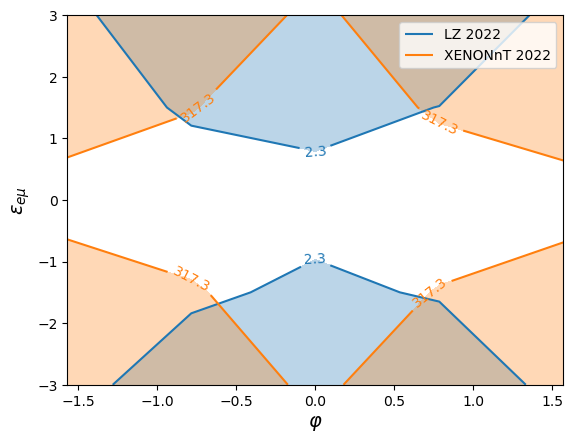

In [24]:
fig, ax = plt.subplots()

plt.contourf(phiGrid, epsGrid, N_LZ, levels=[2.3,np.inf], colors='tab:blue', alpha=0.3) 
contLZ = plt.contour(phiGrid, epsGrid, N_LZ, levels=[2.3], colors='tab:blue') 
plt.contourf(phiGrid, epsGrid, N_xnt22, levels=[300.0+np.sqrt(300), np.inf], colors='tab:orange', alpha=0.3)
contXE = plt.contour(phiGrid, epsGrid, N_xnt22, levels=[ 300.0+np.sqrt(300)], colors='tab:orange',)

plt.clabel(contLZ, inline=1, fontsize=10)
plt.clabel(contXE, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
h2,l1 = contXE.legend_elements()
plt.legend([h1[0], h2[0]], ["LZ 2022", "XENONnT 2022"])

plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\varphi$', size=14)